In [12]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, SimpleRNN, Conv2D, MaxPooling2D

In [13]:
# Load EMNIST letters
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

In [14]:
# Convert dataset to numpy
def ds_to_numpy(ds):
    images = []
    labels = []
    for img, lbl in tfds.as_numpy(ds.take(20000)):  # limit for speed
        images.append(img)
        labels.append(lbl)
    return np.array(images), np.array(labels)

x_train, y_train = ds_to_numpy(ds_train)
x_test, y_test = ds_to_numpy(ds_test)

In [15]:
# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

In [16]:
# Labels 1–26 → 0–25
y_train = y_train - 1
y_test = y_test - 1

# One-hot
y_train_cat = to_categorical(y_train, 26)
y_test_cat = to_categorical(y_test, 26)

labels = [chr(i) for i in range(65, 91)]  # A-Z

In [17]:
# ---------------- RNN ----------------
x_train_rnn = x_train.reshape((-1, 28, 28))
x_test_rnn = x_test.reshape((-1, 28, 28))

rnn_model = Sequential([
    SimpleRNN(128, input_shape=(28,28), activation='relu'),
    Dense(26, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("RNN Model Training : ")
rnn_model.fit(x_train_rnn, y_train_cat, epochs=3, batch_size=128)

RNN Model Training : 
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2695 - loss: 2.4518
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5512 - loss: 1.4405
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6474 - loss: 1.1321


In [18]:
# ---------------- CNN ----------------
x_train_cnn = x_train.reshape((-1,28,28,1))
x_test_cnn = x_test.reshape((-1,28,28,1))

cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(26,activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("CNN Model Training : ")
cnn_model.fit(x_train_cnn, y_train_cat, epochs=3, batch_size=128)

CNN Model Training : 
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6251 - loss: 1.2970
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.8316 - loss: 0.5391
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.8748 - loss: 0.3908


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


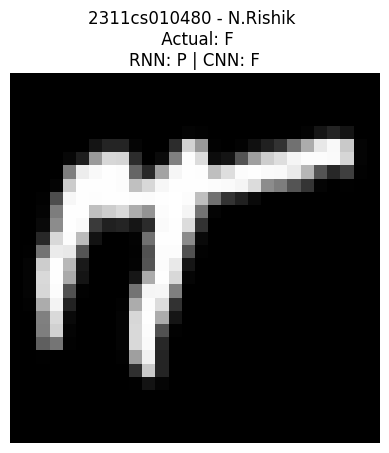

In [19]:
# ---------------- DISPLAY ----------------
sample_index = 4
image = x_test[sample_index]

actual = labels[y_test[sample_index]]

rnn_pred = rnn_model.predict(x_test_rnn[sample_index].reshape(1,28,28))
rnn_label = labels[np.argmax(rnn_pred)]

cnn_pred = cnn_model.predict(x_test_cnn[sample_index].reshape(1,28,28,1))
cnn_label = labels[np.argmax(cnn_pred)]

plt.imshow(image, cmap='gray')
plt.title(f"2311cs010480 - N.Rishik \n Actual: {actual}\nRNN: {rnn_label} | CNN: {cnn_label}")
plt.axis('off')
plt.show()